# Phase 2 Robustness

This notebook evaluates the robustness of the Phase 2 conclusions.

## Main goals
1. Feature ablation
2. Mechanism subgroup modeling
3. Grouped validation by paper / DOI
4. Supplementary support results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedShuffleSplit,
    cross_validate
)
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [2]:
df = pd.read_csv(
    "../data/processed/hydrovoltaic_dataset_phase2_input_utf8.csv",
    encoding="utf-8-sig"
)

print(df.shape)
df.head()

(159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,auxiliary_redox_present,continuous_output,water_interaction_mode,rh_percent,inorganic_electrolyte_present,inorganic_electrolyte_type,inorganic_electrolyte_concentration_wt%,polyelectrolyte_present,active_material_raw,material_class,structure_class,ionic_groups,top_electrode,bottom_electrode,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_Mohm,output_timescale_class,stability_time_min,dominant_mechanism,has_anionic,has_cationic,has_zwitterionic,polyelectrolyte_anionic_raw,polyelectrolyte_cationic_raw,polyelectrolyte_zwitterionic_raw,has_any_polyelectrolyte,estimated_power_density_uW_cm2,log_estimated_power_density,ion_type,mechanism_simple,asym_env,asym_chem,asym_electrode,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,60.0,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,0,0,0,NaN,NaN,NaN,0,0.003750,-2.425853,proton,streaming,1,0,0,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,0,1,evaporation_driven,62.0,0,NaN,NaN,0,ZnO,metal oxide,porous,hydroxyl,Al,Al,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,0,0,0,NaN,NaN,NaN,0,0.002000,-2.698753,anion,streaming,1,0,0,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,lanthanum iron perovskite oxide,semiconductor,porous,hydroxyl,CNT,CNT,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,0,0,0,NaN,NaN,NaN,0,0.009375,-2.027982,anion,streaming,1,1,0,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,0,0,0,NaN,NaN,NaN,0,0.007820,-2.106738,proton,streaming,1,0,0,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,55.0,0,NaN,NaN,0,carbonized rice husk,carbon,porous,"carboxyl, hydroxyl, silanol",CNT,CNT,1,0.0,0.16,0.0400,NaN,NaN,hours,600.0,streaming,0,0,0,NaN,NaN,NaN,0,0.001600,-2.795609,proton,streaming,1,0,0,1,0,0,NaN,0


In [3]:
TARGET = "log_estimated_power_density"
STRATIFY_COL = "mechanism_simple"

FEATURES_MODEL_A = [
    "material_class",
    "structure_class",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "has_anionic",
    "has_cationic",
    "has_zwitterionic",
    "mechanism_simple",
    "water_interaction_mode",
    "top_electrode",
    "bottom_electrode",
    "electrode_symmetry",
    "metal_electrode",
    "ionic_groups",
    "ion_type"
]

FEATURES_MODEL_B = FEATURES_MODEL_A + [
    "log_internal_resistance_Mohm",
    "has_internal_resistance"
]

df_robust = df.dropna(subset=[TARGET, STRATIFY_COL]).copy()

print(df_robust.shape)
print(df_robust[STRATIFY_COL].value_counts(dropna=False))

(159, 52)
mechanism_simple
ion_gradient    107
streaming        52
Name: count, dtype: int64


In [4]:
# Helper functions
def split_feature_types(df_input, features):
    categorical_features = []
    numeric_features = []

    for col in features:
        if pd.api.types.is_numeric_dtype(df_input[col]):
            numeric_features.append(col)
        else:
            categorical_features.append(col)

    return categorical_features, numeric_features


def build_preprocessor(df_input, features):
    categorical_features, numeric_features = split_feature_types(df_input, features)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, categorical_features),
            ("num", numeric_transformer, numeric_features)
        ],
        remainder="drop"
    )

    return preprocessor


def evaluate_rf_cv(
    df_input,
    features,
    target,
    stratify_col,
    dataset_name,
    n_splits=50,
    test_size=0.2,
    random_state=42
):
    all_cols = list(dict.fromkeys(features + [target, stratify_col]))
    df_model = df_input[all_cols].copy()

    X = df_model[features]
    y = df_model[target]
    strata = df_model[stratify_col]

    preprocessor = build_preprocessor(df_model, features)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    sss = StratifiedShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=random_state
    )

    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=sss.split(X, strata),
        scoring={
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error"
        },
        return_train_score=False,
        n_jobs=-1
    )

    cv_r2 = cv_results["test_r2"]
    cv_rmse = -cv_results["test_rmse"]
    cv_mae = -cv_results["test_mae"]

    print(f"\n===== {dataset_name} =====")
    print(f"Raw features: {len(features)}")
    print(f"CV R2 mean ± std: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"CV R2 min / max: {cv_r2.min():.4f} / {cv_r2.max():.4f}")

    return {
        "dataset_name": dataset_name,
        "features": features,
        "cv_r2": cv_r2,
        "cv_rmse": cv_rmse,
        "cv_mae": cv_mae
    }


def summarize_ablation_results(result_dict):
    rows = []

    for name, res in result_dict.items():
        rows.append({
            "Setting": name,
            "Raw_features": len(res["features"]),
            "CV_R2_mean": res["cv_r2"].mean(),
            "CV_R2_std": res["cv_r2"].std(),
            "CV_R2_min": res["cv_r2"].min(),
            "CV_R2_max": res["cv_r2"].max(),
            "CV_RMSE_mean": res["cv_rmse"].mean(),
            "CV_MAE_mean": res["cv_mae"].mean()
        })

    return pd.DataFrame(rows).sort_values("CV_R2_mean", ascending=False).reset_index(drop=True)

In [5]:
# Define ablation feature sets
ablation_sets = {
    "Full_Model_B": FEATURES_MODEL_B,

    "Minus_internalR": [
        f for f in FEATURES_MODEL_B
        if f not in ["log_internal_resistance_Mohm", "has_internal_resistance"]
    ],

    "Minus_mechanism": [
        f for f in FEATURES_MODEL_B
        if f != "mechanism_simple"
    ],

    "Minus_ion_type": [
        f for f in FEATURES_MODEL_B
        if f != "ion_type"
    ],

    "Minus_structure": [
        f for f in FEATURES_MODEL_B
        if f != "structure_class"
    ]
}

for name, feats in ablation_sets.items():
    print(name, len(feats))

Full_Model_B 18
Minus_internalR 16
Minus_mechanism 17
Minus_ion_type 17
Minus_structure 17


In [6]:
# Run ablation study
ablation_results = {}

for setting_name, feature_list in ablation_sets.items():
    ablation_results[setting_name] = evaluate_rf_cv(
        df_input=df_robust,
        features=feature_list,
        target=TARGET,
        stratify_col=STRATIFY_COL,
        dataset_name=setting_name,
        n_splits=50,
        test_size=0.2,
        random_state=42
    )


===== Full_Model_B =====
Raw features: 18
CV R2 mean ± std: 0.1858 ± 0.1541
CV R2 min / max: -0.1851 / 0.4449

===== Minus_internalR =====
Raw features: 16
CV R2 mean ± std: 0.1061 ± 0.2073
CV R2 min / max: -0.5963 / 0.4108

===== Minus_mechanism =====
Raw features: 17
CV R2 mean ± std: 0.1988 ± 0.1498
CV R2 min / max: -0.1618 / 0.4495

===== Minus_ion_type =====
Raw features: 17
CV R2 mean ± std: 0.1828 ± 0.1542
CV R2 min / max: -0.1987 / 0.4873

===== Minus_structure =====
Raw features: 17
CV R2 mean ± std: 0.1005 ± 0.1670
CV R2 min / max: -0.2491 / 0.3760


In [7]:
# Summary table（你应该已经有了，但再规范一下）
summary_ablation = summarize_ablation_results(ablation_results)
summary_ablation

,Setting,Raw_features,CV_R2_mean,CV_R2_std,CV_R2_min,CV_R2_max,CV_RMSE_mean,CV_MAE_mean
0,Minus_mechanism,17,0.198769,0.149812,-0.161829,0.449484,1.146074,0.883079
1,Full_Model_B,18,0.185757,0.154097,-0.185118,0.444935,1.154889,0.887961
2,Minus_ion_type,17,0.182835,0.154239,-0.198693,0.487317,1.156308,0.882762
3,Minus_internalR,16,0.106106,0.207277,-0.596341,0.410828,1.206735,0.923227
4,Minus_structure,17,0.100482,0.166953,-0.249086,0.375978,1.213887,0.929145


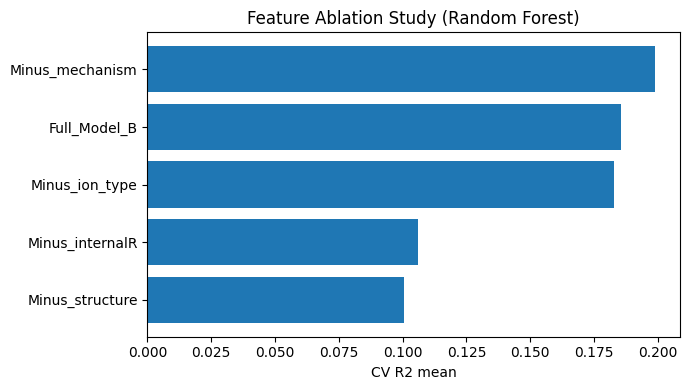

In [8]:
# 排序后的可视化（论文图雏形）
plot_df = summary_ablation.sort_values("CV_R2_mean", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(plot_df["Setting"], plot_df["CV_R2_mean"])

plt.xlabel("CV R2 mean")
plt.title("Feature Ablation Study (Random Forest)")

plt.tight_layout()
plt.show()

## Mechanism Subgroup Modeling

To further evaluate whether feature importance depends on underlying mechanisms,
we perform subgroup modeling within each mechanism category.

In [9]:
# 子模型函数（复用 RF）
def evaluate_subgroup(
    df_input,
    mechanism,
    features
):
    sub = df_input[df_input["mechanism_simple"] == mechanism].copy()

    if len(sub) < 20:
        return None

    return evaluate_rf_cv(
        df_input=sub,
        features=features,
        target=TARGET,
        stratify_col=STRATIFY_COL,
        dataset_name=f"{mechanism}_subgroup",
        n_splits=30,
        test_size=0.2,
        random_state=42
    )

In [10]:
# 跑 subgroup（核心）
subgroup_results = {}

for mech in df_robust["mechanism_simple"].unique():
    res = evaluate_subgroup(
        df_input=df_robust,
        mechanism=mech,
        features=FEATURES_MODEL_B
    )
    
    if res is not None:
        subgroup_results[mech] = res


===== streaming_subgroup =====
Raw features: 18
CV R2 mean ± std: -0.7227 ± 0.5825
CV R2 min / max: -2.4763 / 0.0995

===== ion_gradient_subgroup =====
Raw features: 18
CV R2 mean ± std: 0.0352 ± 0.2075
CV R2 min / max: -0.7705 / 0.2802


In [11]:
# subgroup summary
rows = []

for mech, res in subgroup_results.items():
    rows.append({
        "Mechanism": mech,
        "Rows": len(df_robust[df_robust["mechanism_simple"] == mech]),
        "CV_R2_mean": res["cv_r2"].mean(),
        "CV_R2_std": res["cv_r2"].std()
    })

summary_subgroup = pd.DataFrame(rows).sort_values("CV_R2_mean", ascending=False)
summary_subgroup

,Mechanism,Rows,CV_R2_mean,CV_R2_std
1,ion_gradient,107,0.035235,0.207506
0,streaming,52,-0.722737,0.582540


In [14]:
# Grouped CV（按 DOI）
df_robust["paper_id"] = df_robust["paper_doi"]
from sklearn.model_selection import GroupKFold

def evaluate_grouped_cv(df_input, features):
    df_model = df_input[features + [TARGET, "paper_id"]].dropna().copy()

    X = df_model[features]
    y = df_model[TARGET]
    groups = df_model["paper_id"]

    preprocessor = build_preprocessor(df_model, features)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])

    gkf = GroupKFold(n_splits=5)

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=gkf.split(X, y, groups),
        scoring="r2",
        n_jobs=-1
    )

    return scores["test_score"]

In [15]:
grouped_scores = evaluate_grouped_cv(df_robust, FEATURES_MODEL_B)

print("Grouped CV R2:")
print(grouped_scores)
print("Mean:", grouped_scores.mean())

Grouped CV R2:
[ 0.10053491  0.09007517  0.17163178  0.03095935 -0.34960559]
Mean: 0.008719125494076718


In [16]:
robustness_summary = pd.DataFrame({
    "Test": [
        "Full CV",
        "Grouped CV",
        "Ion-gradient subgroup",
        "Streaming subgroup"
    ],
    "R2_mean": [
        summary_ablation.loc[summary_ablation["Setting"] == "Full_Model_B", "CV_R2_mean"].values[0],
        grouped_scores.mean(),
        summary_subgroup.loc[summary_subgroup["Mechanism"] == "ion_gradient", "CV_R2_mean"].values[0],
        summary_subgroup.loc[summary_subgroup["Mechanism"] == "streaming", "CV_R2_mean"].values[0],
    ]
})

robustness_summary

,Test,R2_mean
0,Full CV,0.185757
1,Grouped CV,0.008719
2,Ion-gradient subgroup,0.035235
3,Streaming subgroup,-0.722737
